## Import libraries

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import (
    cross_validate, cross_val_predict,
)
from sklearn.metrics import classification_report, confusion_matrix, make_scorer
from xgboost import XGBClassifier

## Load data

In [30]:
BINARY_TARGET = False
INCLUDE_TEST_FOR_FEATURE_SELECT = True
FULL_CLINICAL = False

In [31]:

clinical = pd.read_csv(
    '../dataset/created/clinical.csv',
    index_col='Unnamed: 0',
    low_memory=False
)
clinical.columns = clinical.columns.str.strip()

if BINARY_TARGET == True:
    clinical = clinical[clinical['pfs_label'].isin([0,2])]
    clinical['pfs_label'] = clinical['pfs_label'].replace(2, 1)

y = clinical['pfs_label']
x = clinical.drop(['patientID', 'pfs_label', 'source', 'brain_metastasis'], axis=1)

print(x.head())
print(f"\nTarget distribution:\n{y.value_counts().sort_index()}")

      sex  age AJCC_stage M_stage       LDH immunotherapy_treatment  \
0    male   56         IV     NaN    normal                      no   
1    male   86         IV     NaN    normal                      no   
2  female   47         IV     NaN    normal                      no   
3  female   50         IV     NaN       NaN                      no   
4  female   47         IV     NaN  elevated                      no   

  pre_MAPKi_treatment  cobimetinib  dabrafenib  trametinib  vemurafenib  \
0                  no            0           1           1            0   
1                  no            0           1           0            0   
2                  no            0           1           1            0   
3                  no            0           0           0            1   
4                  no            0           1           1            0   

   C195W  K601I  MND  R558Q  V600E  V600K  V600R  
0      0      0    0      0      1      0      0  
1      0      0    0

In [32]:
# Clinical columns that need preprocessing
clinical_ordinal_col = ['M_stage']
clinical_categorical_cols = [
    'sex', 'AJCC_stage', 'LDH',
    'immunotherapy_treatment', 'pre_MAPKi_treatment'
]
clinical_numeric_col = ['age']

drug_braf_cols = [
    'cobimetinib', 'trametinib', 'dabrafenib', 'vemurafenib',
    'C195W', 'K601I', 'R558Q', 'MND', 'V600E', 'V600K', 'V600R'
]

print(f"\nClinical features: {len(clinical_ordinal_col) + len(clinical_categorical_cols) + len(clinical_numeric_col)}")
print(f"Drug/BRAF dummies: {len(drug_braf_cols)}")



Clinical features: 7
Drug/BRAF dummies: 11


## Preprocessing pipeline

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

clinical_preprocessor = ColumnTransformer(
    transformers=[
        ('m_stage', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OrdinalEncoder(
                categories=[['M1A', 'M1B', 'M1C']],
                handle_unknown='use_encoded_value',
                unknown_value=np.nan
            )),
        ]), clinical_ordinal_col),

        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
        ]), clinical_categorical_cols),

        ('age', SimpleImputer(strategy='median'), clinical_numeric_col),
        ('drug_braf', 'passthrough', drug_braf_cols)
    ],
    remainder='passthrough'
)  

x_processed = clinical_preprocessor.fit_transform(x)
x_processed = pd.DataFrame(x_processed, columns=clinical_preprocessor.get_feature_names_out())
x_processed

# pipeline = Pipeline([
#     ('preprocess', clinical_preprocessor),
#     # ('rfe', RFECV(
#     #     estimator=RandomForestClassifier(random_state=42),
#     #     cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
#     #     n_jobs=-1,
#     #     step=1
#     # ))
# ])

# lr_pipeline = Pipeline([
#     ('preprocess', clinical_preprocessor),
#     # ('rfe', RFECV(
#     #     estimator=RandomForestClassifier(random_state=42),
#     #     cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
#     #     n_jobs=-1,
#     #     step=1
#     # )),
#     ('scaler', StandardScaler())
# ])

,m_stage__M_stage,categorical__sex_female,categorical__sex_male,categorical__AJCC_stage_IIIC,categorical__AJCC_stage_IV,categorical__LDH_elevated,categorical__LDH_normal,categorical__immunotherapy_treatment_no,categorical__immunotherapy_treatment_yes,categorical__pre_MAPKi_treatment_Chemotherapy,...,drug_braf__trametinib,drug_braf__dabrafenib,drug_braf__vemurafenib,drug_braf__C195W,drug_braf__K601I,drug_braf__R558Q,drug_braf__MND,drug_braf__V600E,drug_braf__V600K,drug_braf__V600R
0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,2.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,2.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,2.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
410,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
411,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
412,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
413,2.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## RFE on FULL data

In [34]:
rfecv = RFECV(
    estimator=RandomForestClassifier(random_state=42),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    step=1
)

x_rfe = rfecv.fit_transform(x_processed, y)
x_rfe = pd.DataFrame(x_rfe, columns=rfecv.get_feature_names_out())
x_rfe

,m_stage__M_stage,categorical__sex_male,categorical__LDH_elevated,age__age,drug_braf__vemurafenib,drug_braf__V600E
0,2.0,1.0,0.0,56.0,0.0,1.0
1,2.0,1.0,0.0,86.0,0.0,1.0
2,2.0,0.0,0.0,47.0,0.0,1.0
3,2.0,0.0,0.0,50.0,1.0,1.0
4,2.0,0.0,1.0,47.0,0.0,0.0
...,...,...,...,...,...,...
410,2.0,1.0,0.0,47.0,1.0,1.0
411,0.0,1.0,0.0,39.0,1.0,1.0
412,2.0,1.0,0.0,84.0,0.0,1.0
413,2.0,0.0,0.0,41.0,1.0,1.0


In [35]:
x = x_rfe

## Cross-validation

In [36]:
if BINARY_TARGET == True:
    xgboost_clf = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
    )
else:
    xgboost_clf = XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        eval_metric='mlogloss',
        random_state=42,
    )
    
lr_clf = LogisticRegression(
    solver='saga',
    class_weight='balanced',
    max_iter=5000,
    random_state=42,
)

In [37]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
    }

    xgboost_clf.set_params(**params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(xgboost_clf, x, y, cv=cv, scoring='f1_macro', n_jobs=-1)

    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200)

print("Best params:", study.best_params)
print("Best CV AUC:", study.best_value)

[I 2026-04-08 14:13:00,199] A new study created in memory with name: no-name-d3d47b3b-4aec-4e5b-8c80-1798235d7130
[I 2026-04-08 14:13:01,500] Trial 0 finished with value: 0.23301345144356955 and parameters: {'n_estimators': 82, 'max_depth': 6, 'learning_rate': 0.020709121236819207, 'subsample': 0.8260054169557022, 'colsample_bytree': 0.41076637248511066, 'reg_alpha': 0.14464766336475562, 'reg_lambda': 0.24996823238942634, 'min_child_weight': 19, 'gamma': 3.676309576373684}. Best is trial 0 with value: 0.23301345144356955.
[I 2026-04-08 14:13:01,601] Trial 1 finished with value: 0.26986451842560955 and parameters: {'n_estimators': 278, 'max_depth': 6, 'learning_rate': 0.29415088180018073, 'subsample': 0.5195205719267073, 'colsample_bytree': 0.36309928952377096, 'reg_alpha': 0.6055530408390587, 'reg_lambda': 0.2971162381985832, 'min_child_weight': 1, 'gamma': 4.865228795628361}. Best is trial 1 with value: 0.26986451842560955.
[I 2026-04-08 14:13:01,668] Trial 2 finished with value: 0.24

Best params: {'n_estimators': 366, 'max_depth': 6, 'learning_rate': 0.2221777577480454, 'subsample': 0.5619063169383459, 'colsample_bytree': 0.49199827554618436, 'reg_alpha': 0.04343895394990281, 'reg_lambda': 4.2330381403264, 'min_child_weight': 11, 'gamma': 0.5474436171998434}
Best CV AUC: 0.49608624768327775


In [38]:
def objective_lr(trial):
    params = {
        'C': trial.suggest_float('C', 0.001, 10.0, log=True),
        'l1_ratio': trial.suggest_float('l1_ratio', 0.0, 1.0),
    }

    lr_clf.set_params(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(lr_clf, x, y, cv=cv, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=200)

print("Best params:", study_lr.best_params)
print("Best CV AUC:", study_lr.best_value)

[I 2026-04-08 14:13:14,277] A new study created in memory with name: no-name-3f05496f-196f-45d4-9ae6-6d71144e83c3
[I 2026-04-08 14:13:14,487] Trial 0 finished with value: 0.4700000325645277 and parameters: {'C': 0.5152966989667248, 'l1_ratio': 0.7010557975440531}. Best is trial 0 with value: 0.4700000325645277.
[I 2026-04-08 14:13:14,581] Trial 1 finished with value: 0.481508624824923 and parameters: {'C': 0.1048801117711204, 'l1_ratio': 0.12115773835203347}. Best is trial 1 with value: 0.481508624824923.
[I 2026-04-08 14:13:14,675] Trial 2 finished with value: 0.2829919165841085 and parameters: {'C': 0.005325133805318382, 'l1_ratio': 0.731239971058142}. Best is trial 1 with value: 0.481508624824923.
[I 2026-04-08 14:13:14,760] Trial 3 finished with value: 0.4454324150201473 and parameters: {'C': 0.3561364648183371, 'l1_ratio': 0.2076224076518689}. Best is trial 1 with value: 0.481508624824923.
[I 2026-04-08 14:13:14,837] Trial 4 finished with value: 0.3000241514428188 and parameters: 

Best params: {'C': 0.09935273120597693, 'l1_ratio': 0.6273617394410073}
Best CV AUC: 0.4987293569716883


Test ROC-AUC (OVO) : 0.664 ± 0.050
Test Macro F1      : 0.499 ± 0.058
Train ROC-AUC (OVO): 0.741 ± 0.014
Train Macro F1     : 0.537 ± 0.012


              precision    recall  f1-score   support

  Short resp       0.66      0.74      0.70       223
Intermediate       0.42      0.41      0.41       106
   Long resp       0.48      0.34      0.39        86

    accuracy                           0.57       415
   macro avg       0.52      0.50      0.50       415
weighted avg       0.56      0.57      0.56       415



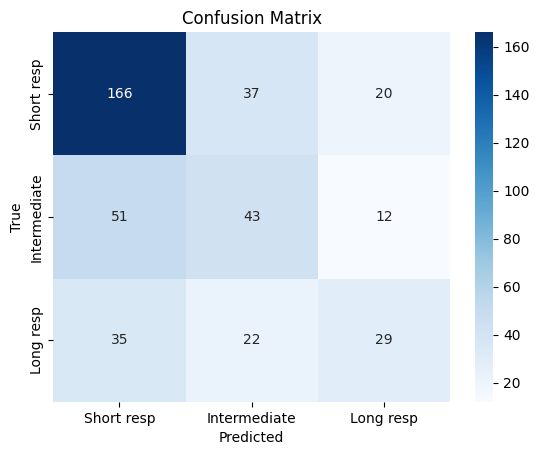

In [39]:
from sklearn.ensemble import VotingClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgboost_clf.set_params(**study.best_params)
lr_clf.set_params(**study_lr.best_params)

lr_pipe = Pipeline([('scaler', StandardScaler()), ('clf', lr_clf)])

voting_clf = VotingClassifier(
    estimators=[('xgb', xgboost_clf), ('lr', lr_pipe)],
    voting='soft',
    weights=[1, 1]
)

clf = voting_clf

results = cross_validate(
    clf, x, y,
    cv=cv,
    scoring=['roc_auc_ovo', 'f1_macro'],
    return_train_score=True,
    n_jobs=-1
)
y_pred = cross_val_predict(
    clf, x, y, cv=cv,
    n_jobs=-1
)

if BINARY_TARGET == True:
    target_names = ['Short resp', 'Long resp']
else:
    target_names = ['Short resp', 'Intermediate', 'Long resp']

print(f"Test ROC-AUC (OVO) : {results['test_roc_auc_ovo'].mean():.3f} ± {results['test_roc_auc_ovo'].std():.3f}")
print(f"Test Macro F1      : {results['test_f1_macro'].mean():.3f} ± {results['test_f1_macro'].std():.3f}")
print(f"Train ROC-AUC (OVO): {results['train_roc_auc_ovo'].mean():.3f} ± {results['train_roc_auc_ovo'].std():.3f}")
print(f"Train Macro F1     : {results['train_f1_macro'].mean():.3f} ± {results['train_f1_macro'].std():.3f}")

print("\n")
print(classification_report(
    y, y_pred,
    target_names=target_names
))

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=target_names,
            yticklabels=target_names,
            cmap='Blues')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()